In [1]:
import tensorflow as tf
import pandas as pd


def read_tensorboard_data(log_dir):
    data = []
    for event_file in tf.io.gfile.glob(f"{log_dir}/events.out.tfevents.*"):
        for event in tf.compat.v1.train.summary_iterator(event_file):
            for value in event.summary.value:
                data.append({"step": event.step, "tag": value.tag, "value": value.simple_value})
    return pd.DataFrame(data)


log_dir = "../training_scripts/runs/gllm_pretraining_logs_1"
df_1 = read_tensorboard_data(log_dir)
df_1 = df_1[df_1["tag"] == "step/train_loss"]

2024-09-29 12:15:51.393290: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-29 12:15:51.438940: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-29 12:15:51.439878: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-29 12:15:52.147782: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`


In [2]:
df_2 = read_tensorboard_data("../training_scripts/runs/gllm_pretraining_logs_2")
df_2 = df_2[df_2["tag"] == "step/train_loss"]

In [3]:
import numpy as np

new_steps = np.arange(5000, 5000 + len(df_2))

# Assign new values to the 'step' column to make the plot continuous
df_2["step"] = new_steps

In [4]:
all_step_losses = pd.concat([df_1, df_2])

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size), "valid") / window_size


x = np.array(all_step_losses["step"])
y = np.array(all_step_losses["value"])

window_size = 20  # Adjust this value to control the smoothing level
y_smoothed = moving_average(y, window_size)
x_smoothed = x[window_size - 1 :]

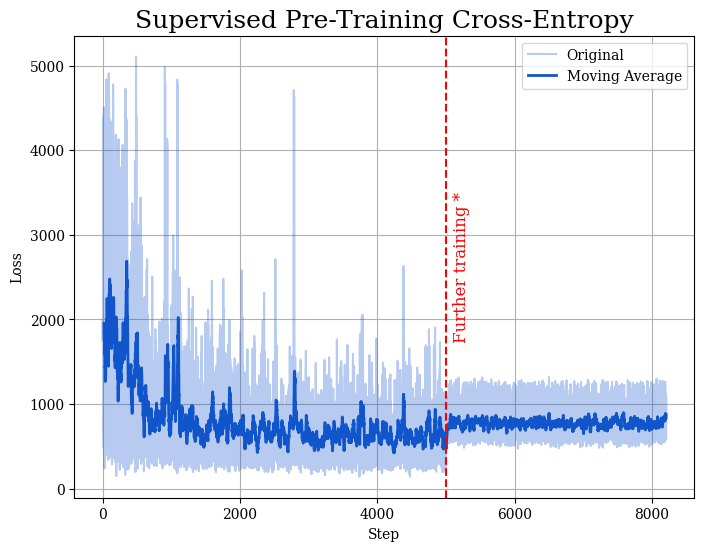

In [6]:
plt.figure(figsize=(8, 6))
plt.plot(x, y, label="Original", alpha=0.3, color="#1055cc")
plt.plot(x_smoothed, y_smoothed, label="Moving Average", linewidth=2, color="#1055cc")
plt.axvline(x=5000, color="r", linestyle="--")
plt.annotate(
    "Further training *",
    xy=(5000, 0.5),  # Position of the line
    xytext=(5, 160),  # Offset for the text
    textcoords="offset points",  # Use offset from xy in points
    ha="left",  # Horizontal alignment
    va="center",  # Vertical alignment
    rotation=90,  # Rotate text to be parallel to the line
    fontsize=12,
    color="#FF0000",
    font="serif",
    fontfamily="serif",
)  # Match color with the line
plt.yticks(font="serif")
plt.xticks(font="serif")
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 17
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.title("Supervised Pre-Training Cross-Entropy", fontdict={"family": "serif"})
plt.xlabel("Step", fontdict={"family": "serif"})
plt.ylabel("Loss", fontdict={"family": "serif"})
plt.grid(True)
legend = plt.legend(prop="serif")
plt.savefig("./figures/Supervised Pre-training cross-entropy per step loss.pdf", format="pdf", bbox_inches="tight")